# Supplementary code for paper "Interpretable Recognition of Cognitive Distortions in Natural Language Texts"

## Evaluating Hybrid Model

- Create Joined Model for 3-split Shreevastava models based on iclusion thresold IT=10
- Save output to  ```../../data/models/distortions/shreevastava2021/joint-10``` (temporary)
- Add distortions according to work by Bollen,
- Add distortions-specific patterns according to ChatGPT, 
- Manually edit removing overfiting-incured junk
- Synonymize the reminder
- Sort and eliminate duplicates
- Save output to  ```../../data/models/distortions/shreevastava2021/joint-cleaned-10``` (committed)
- Evaluate according to ```shreevastava_llm.ipynb``` - TODO

In [38]:
import os, sys
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
import datetime as dt
import plotly.graph_objects as go
import shutil

#force reimport
if 'api' in sys.modules:
    del sys.modules['api']
if 'plot' in sys.modules:
    del sys.modules['plot']
if 'util' in sys.modules:
    del sys.modules['util']
if 'recognition_evaluators' in sys.modules:
    del sys.modules['recognition_evaluators']

from api import TextMetrics, load_ngrams, punct, tokenize_re, build_ngrams, Learner
from plot import plot_dict, plot_dict_bars, matrix_plot, plot_bar_from_list, \
    build_triple_list, build_triple_matrix, plot_bar_from_list_minmax
from util import dictcount, contains_seq, agg_min_max_avg_mpe
from recognition_evaluators import df2labeled, language_metrics, our_evaluator_test, our_evaluator_tm, our_evaluator_top, \
    our_evaluator_true, our_evaluator_false, our_evaluator_random, pre_rec_f1_from_counts, evaluate_tm_df, evaluate_metrics, evaluate_model, \
    full_test_circle, dictval, our_evaluator_top1, summarize_full_test_circle

grand_t0 = dt.datetime.now()

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


In [39]:
# Paper section: "Models with Data Provided" 
# The first and so far the only one publicly available dataset with multiple distortions 
# markup based or real world interactions between therapists and clients (Shreevastava 2021)

# Dataset: Multiple Distorions (sagarikashreevastava)
# Paper: https://aclanthology.org/2021.clpsych-1.17/
# Data: https://www.kaggle.com/datasets/sagarikashreevastava/cognitive-distortion-detetction-dataset

DS = 'Shreevastava21'

# !pip install kagglehub
import kagglehub
multiclass_dataset_path = kagglehub.dataset_download("sagarikashreevastava/cognitive-distortion-detetction-dataset")
multiclass_dataset_file_path = multiclass_dataset_path + "/Annotated_data.csv"

df = pd.read_csv(multiclass_dataset_file_path) 
df = df.drop('Id_Number', axis=1) # delete columnb with id 

df

,Patient Question,Distorted part,Dominant Distortion,Secondary Distortion (Optional)
0,"Hello, I have a beautiful,smart,outgoing and a...",The voice are always fimilar (someone she know...,Personalization,NaN
1,Since I was about 16 years old I’ve had these ...,I feel trapped inside my disgusting self and l...,Labeling,Emotional Reasoning
2,So I’ve been dating on and off this guy for a...,NaN,No Distortion,NaN
3,My parents got divorced in 2004. My mother has...,NaN,No Distortion,NaN
4,I don’t really know how to explain the situati...,I refused to go because I didn’t know if it wa...,Fortune-telling,Emotional Reasoning
...,...,...,...,...
2525,I’m a 21 year old female. I spent most of my l...,NaN,No Distortion,NaN
2526,I am 21 female and have not had any friends fo...,Now I am at university my peers around me all ...,Overgeneralization,NaN
2527,From the U.S.: My brother is 19 years old and ...,He claims he’s severely depressed and has outb...,Mental filter,Mind Reading
2528,From the U.S.: I am a 21 year old woman who ha...,NaN,No Distortion,NaN


### Evaluate baseline model (Arinicheva and Kolonin 2025)

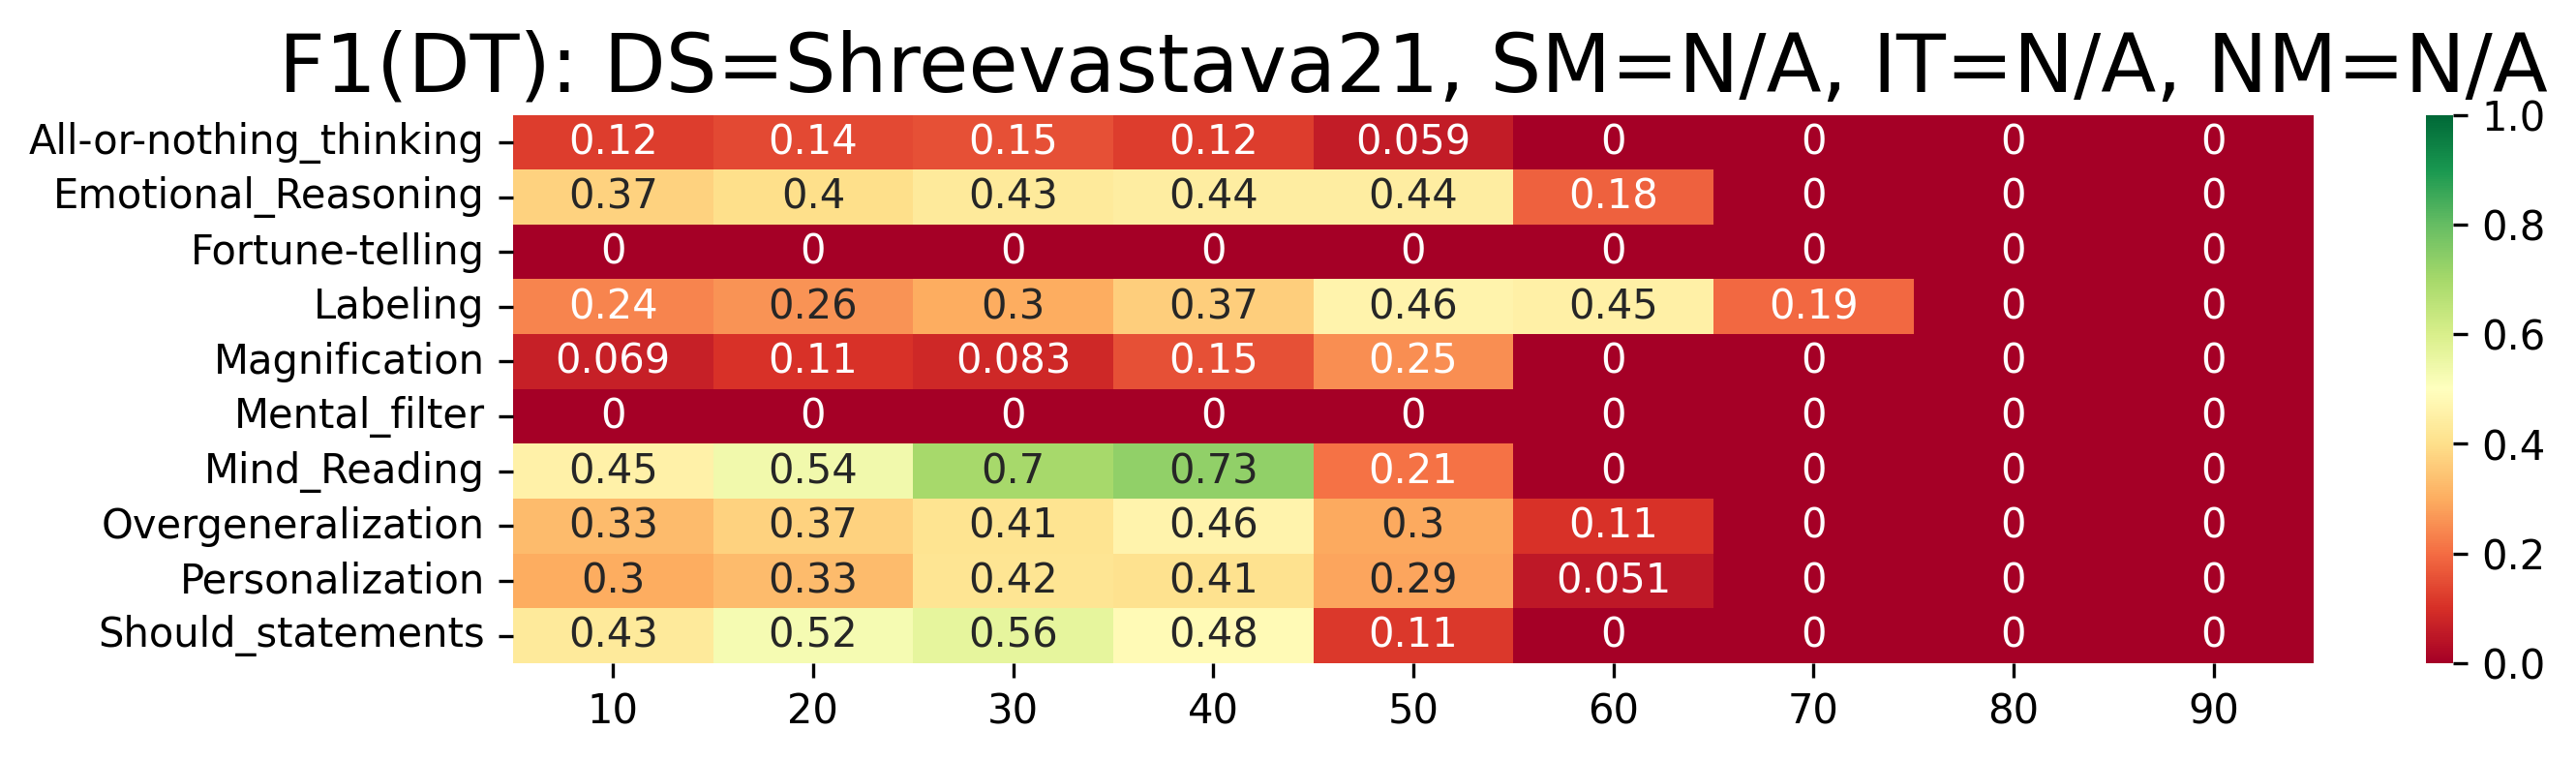

('N/A', 'N/A', 'N/A', 40, 0.316973235175538, {'All-or-nothing_thinking': 0.1218274111675127, 'Emotional_Reasoning': 0.44444444444444436, 'Fortune-telling': 0, 'Labeling': 0.36585365853658536, 'Magnification': 0.15384615384615385, 'Mental_filter': 0, 'Mind_Reading': 0.7333333333333333, 'Overgeneralization': 0.4615384615384615, 'Personalization': 0.4074074074074074, 'Should_statements': 0.4814814814814815})
['All-or-nothing_thinking', 'Emotional_Reasoning', 'Fortune-telling', 'Labeling', 'Magnification', 'Mental_filter', 'Mind_Reading', 'Overgeneralization', 'Personalization', 'Should_statements']
[0.12, 0.44, 0, 0.37, 0.15, 0, 0.73, 0.46, 0.41, 0.48]
0.316


In [40]:
# Evaluate baseline model (Arinicheva and Kolonin 2025) without splits

all_metricsmap = {'All-or-nothing_thinking':'dichotomous-reasoning',
              'Fortune-telling':'fortune-telling',
              'Mental_filter':'mental-filtering',
              'Overgeneralization':'overgeneralizing',
              'Labeling':'labeling',
              'Mind_Reading':'mindreading',
              'Personalization':'personalizing',
              'Emotional_Reasoning':'emotional-reasoning',
              'Magnification':'magnification',
              'Should_statements':'should-statement'}

def language_metrics(lang,metrics_filenames,path):
    metrics = {}
    for m in metrics_filenames:
        filename = metrics_filenames[m] if type(metrics_filenames) == dict else m
        metrics[m] = path + lang + '/' + filename + '.txt'
    return metrics

tm_base = TextMetrics(language_metrics('',all_metricsmap,path='../../data/models/distortions/ours')
                  ,encoding="utf-8",metric_logarithmic=True,debug=False)

detection_thresholds = [10,20,30,40,50,60,70,80,90]

accumulator = []
evaluate_metrics(tm_base, df, 'N/A', detection_thresholds, DS, list(all_metricsmap), n_max='N/A', 
                selection_metric = 'N/A', f1_score=True, evaluator=our_evaluator_top1, accumulator=accumulator)

best = sorted(accumulator, key=lambda x: (-x[4]))[0]
print(best)
labels = sorted(list(best[5]))
print(labels)
numbers_arinicheva = [round(best[5][label],2) for label in labels]
print(numbers_arinicheva)
print(sum(numbers_arinicheva)/len(numbers_arinicheva))

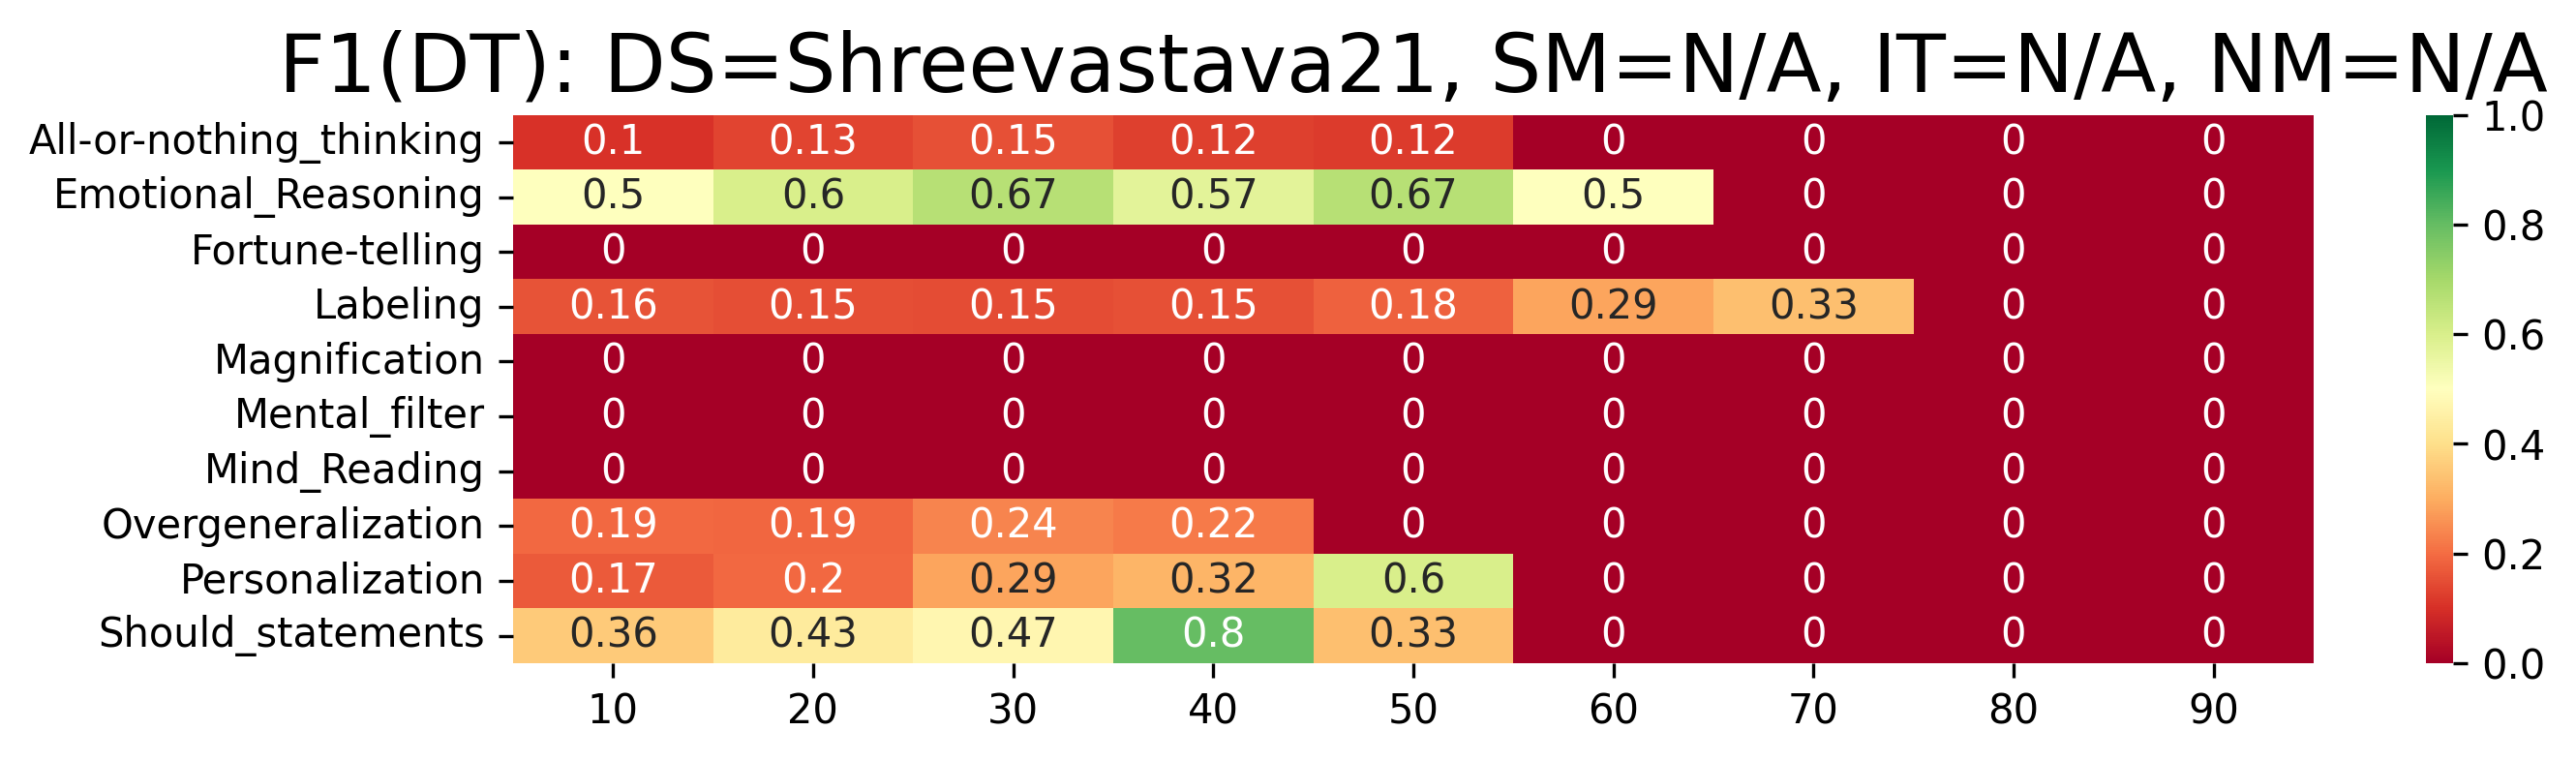

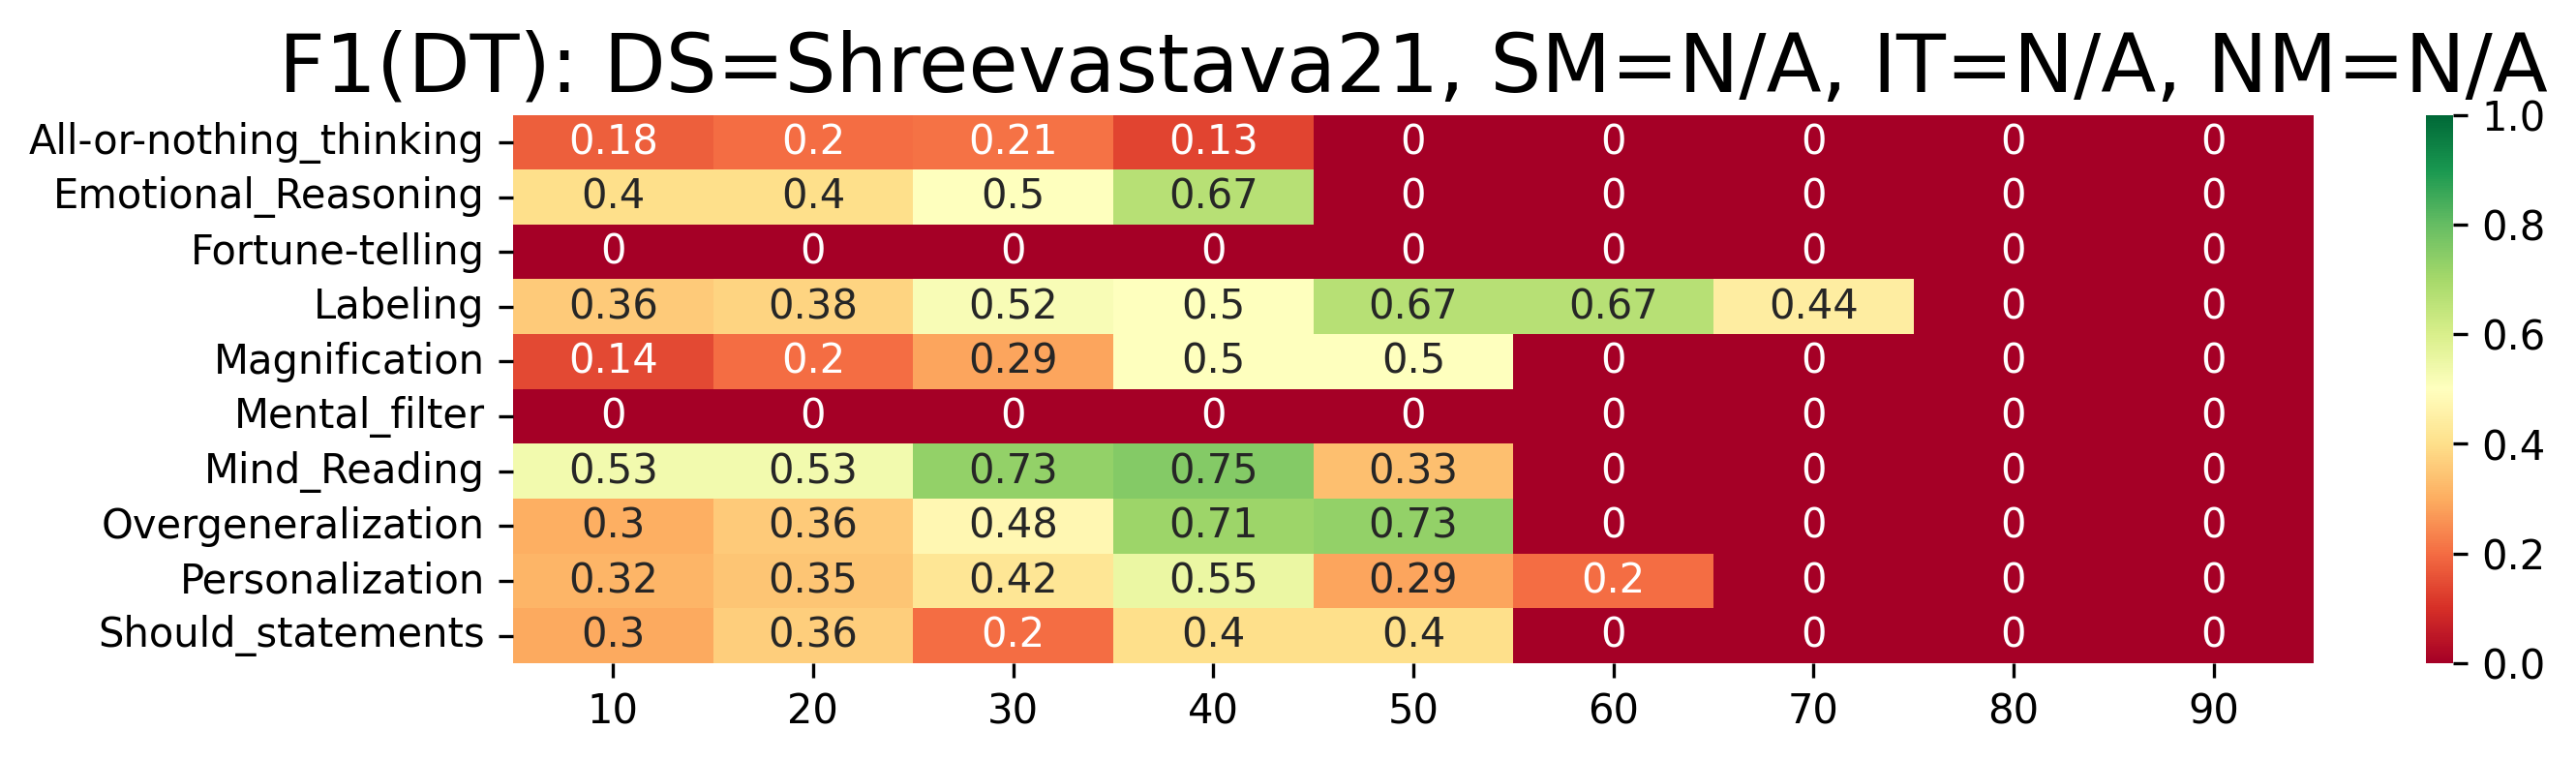

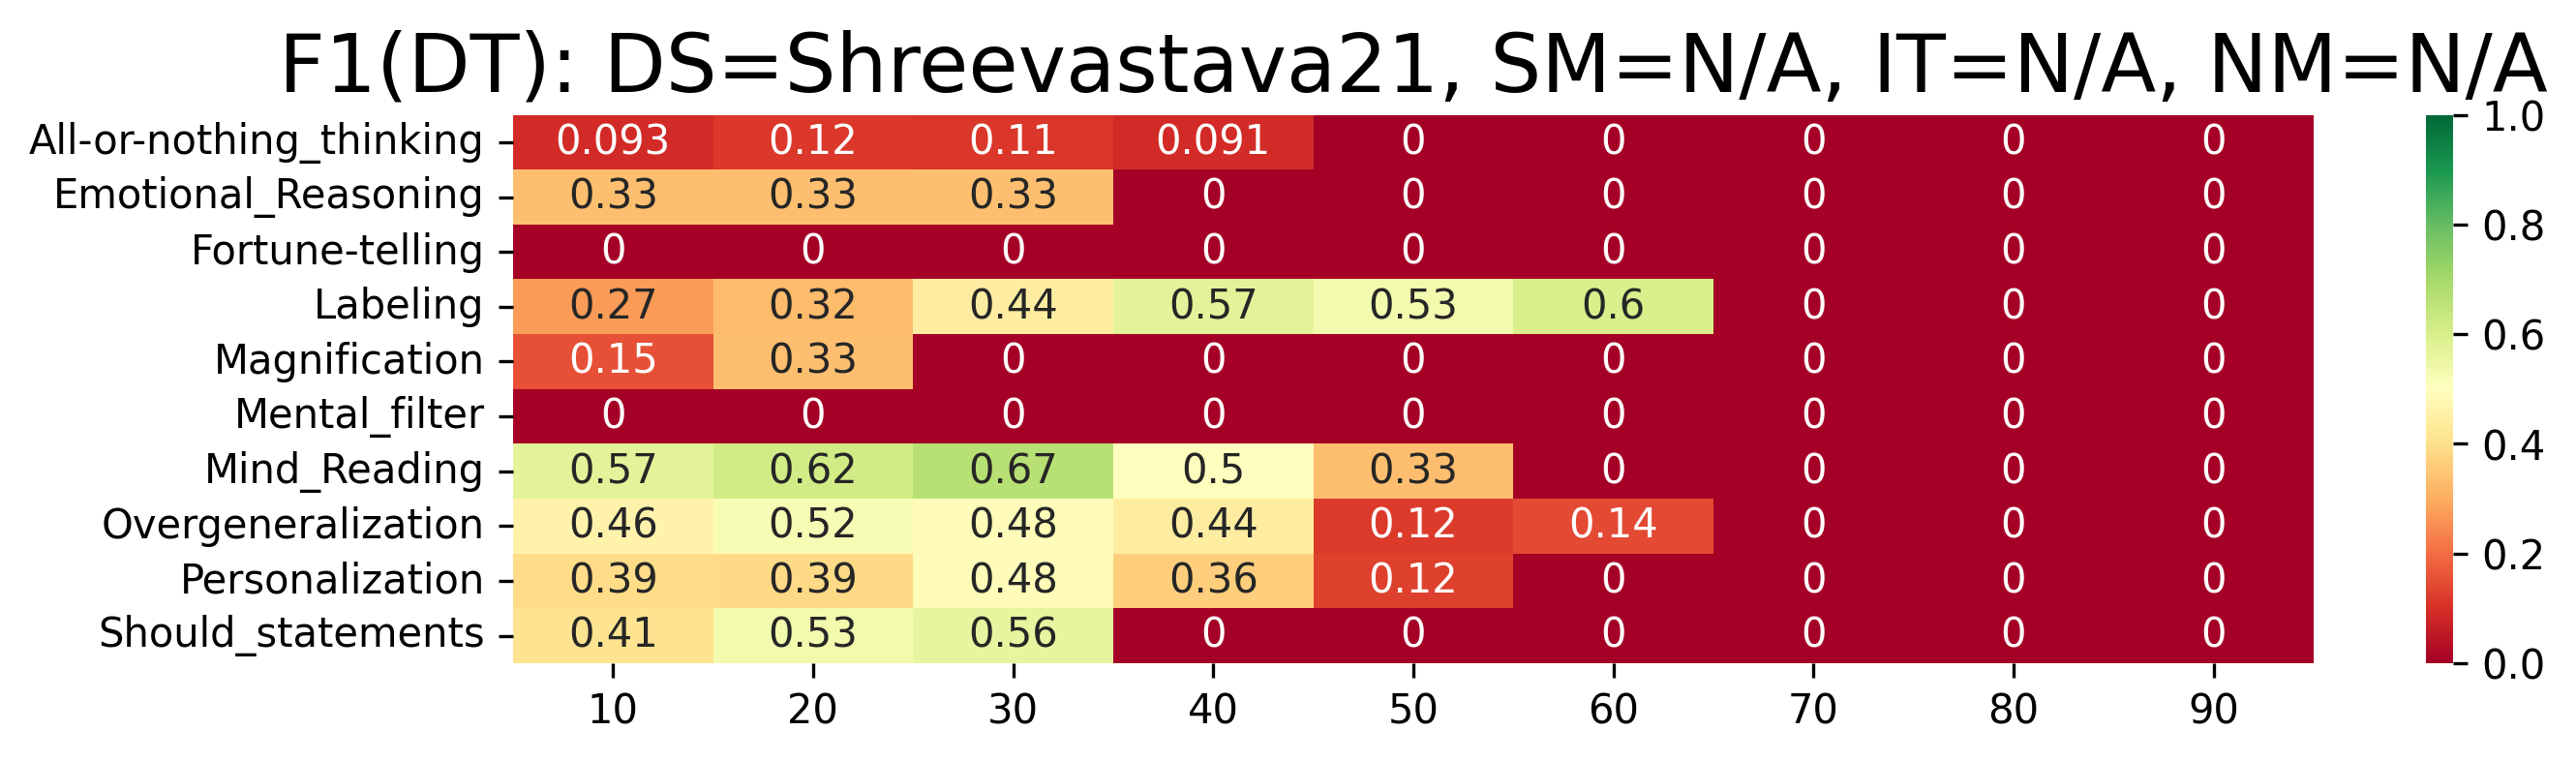

('N/A',
 'N/A',
 'N/A',
 30,
 0.19602576073164307,
 0.3335602984440194,
 0.2794120518819945,
 19.895656036475824)

In [41]:
# Evaluate baseline model (Arinicheva and Kolonin 2025) within 3 splits
splits = [0,1,2]
validation_fraction = 5
results_base = []
for shift in splits:
    test_df  = df[(df.index + shift) % validation_fraction == 0]
    accumulator_base = []
    evaluate_metrics(tm_base, test_df, 'N/A', detection_thresholds, DS, list(all_metricsmap), n_max='N/A', 
                selection_metric = 'N/A', f1_score=True, evaluator=our_evaluator_top1, accumulator=accumulator_base)
    results_base.append(accumulator_base)

# Print F1 performance of baseline model (Arinicheva and Kolonin 2025) within 3 splits
summary_base = []
for l1,l2,l3 in zip(results_base[0],results_base[1],results_base[2]):
    summary_base.append( l1[0:4] + agg_min_max_avg_mpe((l1[4],l2[4],l3[4])))
summary_base = sorted(summary_base, key=lambda x: (-x[6],x[3])) # sort by -F1avg, DT
summary_base[0]

### Create Joined Model for 3-split Shreevastava models based on inclusion thresold IT=10

In [42]:
root_path = '../../data/models/distortions/shreevastava2021/'
IT = 10
if not os.path.exists(root_path+'joint'):
    os.makedirs(root_path+f'joint-{IT}')
unionset_files = {}
for split_name in [f'multiclass-1-{IT}',f'multiclass-2-{IT}',f'multiclass-3-{IT}']:
    split_path = root_path+split_name+'/'
    print(split_path)
    files = os.listdir(split_path)
    print(files)
    for file in files:
        if file == 'No_Distortion.txt':
            continue
        if not file in unionset_files:
            unionset_files[file] = {}
        union = unionset_files[file]
        ngrams = load_ngrams(split_path+file,encoding="utf-8")
        for ngram in ngrams:
            dictcount(union,ngram)
for file in unionset_files:
    cross = set()
    union = unionset_files[file]
    for ngram in union:
        if union[ngram] >= 3:
            cross.add(ngram)
    cross = list(cross)
    cross.sort()
    with open(root_path+f'joint-{IT}/'+file, "w", encoding="utf-8") as f:
        for ngram in cross:
            ngram_str = ' '.join(ngram)
            f.write(f"{ngram_str}\n")


FileExistsError: [Errno 17] File exists: '../../data/models/distortions/shreevastava2021/joint-10'

In [ ]:
# Evaluate joint without splits

all_metrics = {'All-or-nothing_thinking',
              'Fortune-telling',
              'Mental_filter',
              'Overgeneralization',
              'Labeling',
              'Mind_Reading',
              'Personalization',
              'Emotional_Reasoning',
              'Magnification',
              'Should_statements'}

def language_metrics(lang,metrics_filenames,path):
    metrics = {}
    for m in metrics_filenames:
        filename = metrics_filenames[m] if type(metrics_filenames) == dict else m
        metrics[m] = path + lang + '/' + filename + '.txt'
    return metrics

tm_joint = TextMetrics(language_metrics('',all_metrics,path=root_path+f'joint-{IT}')
                  ,encoding="utf-8",metric_logarithmic=True,debug=False)

detection_thresholds = [10,20,30,40,50,60,70,80,90]

accumulator = []
evaluate_metrics(tm_joint, df, 'N/A', detection_thresholds, DS, list(all_metricsmap), n_max='N/A', 
                selection_metric = 'N/A', f1_score=True, evaluator=our_evaluator_top1, accumulator=accumulator)

best = sorted(accumulator, key=lambda x: (-x[4]))[0]
print(best)
labels = sorted(list(best[5]))
print(labels)
numbers_joint = [round(best[5][label],2) for label in labels]
print(numbers_joint)
print(sum(numbers_joint)/len(numbers_joint))

In [ ]:
# Evaluate joint model within 3 splits
splits = [0,1,2]
validation_fraction = 5
results_joint = []
for shift in splits:
    test_df  = df[(df.index + shift) % validation_fraction == 0]
    accumulator_base = []
    evaluate_metrics(tm_joint, test_df, 'N/A', detection_thresholds, DS, list(all_metricsmap), n_max='N/A', 
                selection_metric = 'N/A', f1_score=True, evaluator=our_evaluator_top1, accumulator=accumulator_base)
    results_joint.append(accumulator_base)

# Print F1 performance of joint model

summary_joint = []
for l1,l2,l3 in zip(results_joint[0],results_joint[1],results_joint[2]):
    summary_joint.append( l1[0:4] + agg_min_max_avg_mpe((l1[4],l2[4],l3[4])))
summary_joint = sorted(summary_joint, key=lambda x: (-x[6],x[3])) # sort by -F1avg, DT
summary_joint[0]

### Add distortions according to work by Bollen and ChatGPT, remove irrrelevant and high-frequency junk,  synonymize the reminder

In [ ]:
bollen_files = os.listdir('../../data/models/distortions/ours')
print(files)
for file in files:
    print(file)


In [43]:
src_path = '../../data/models/distortions/shreevastava2021/joint-cleaned-10'
dest_path = '../../data/models/distortions/ours26'
if not os.path.exists(edited_path):
    os.makedirs(edited_path)
print(edited_path)
print()


all_metricsmap_12 = {'All-or-nothing_thinking':'dichotomous-reasoning',
              'Fortune-telling':'fortune-telling',
              'Mental_filter':'mental-filtering',
              'Overgeneralization':'overgeneralizing',
              'Labeling':'labeling',
              'Mind_Reading':'mindreading',
              'Personalization':'personalizing',
              'Emotional_Reasoning':'emotional-reasoning',
              'Magnification':'magnification',
              'Should_statements':'should-statement',
              'Catastrophizing':'catastrophizing',
              'Disqualifying_positive':'disqualifying-positive'}

for m in all_metricsmap_12:
    src = m + '.txt'
    dest = all_metricsmap_12[m] + '.txt'
    print(src,'\t',dest)
    shutil.copy(src_path + '/' + src, dest_path + '/' + dest)


../../data/models/distortions/ours26

All-or-nothing_thinking.txt 	 dichotomous-reasoning.txt
Fortune-telling.txt 	 fortune-telling.txt
Mental_filter.txt 	 mental-filtering.txt
Overgeneralization.txt 	 overgeneralizing.txt
Labeling.txt 	 labeling.txt
Mind_Reading.txt 	 mindreading.txt
Personalization.txt 	 personalizing.txt
Emotional_Reasoning.txt 	 emotional-reasoning.txt
Magnification.txt 	 magnification.txt
Should_statements.txt 	 should-statement.txt
Catastrophizing.txt 	 catastrophizing.txt
Disqualifying_positive.txt 	 disqualifying-positive.txt


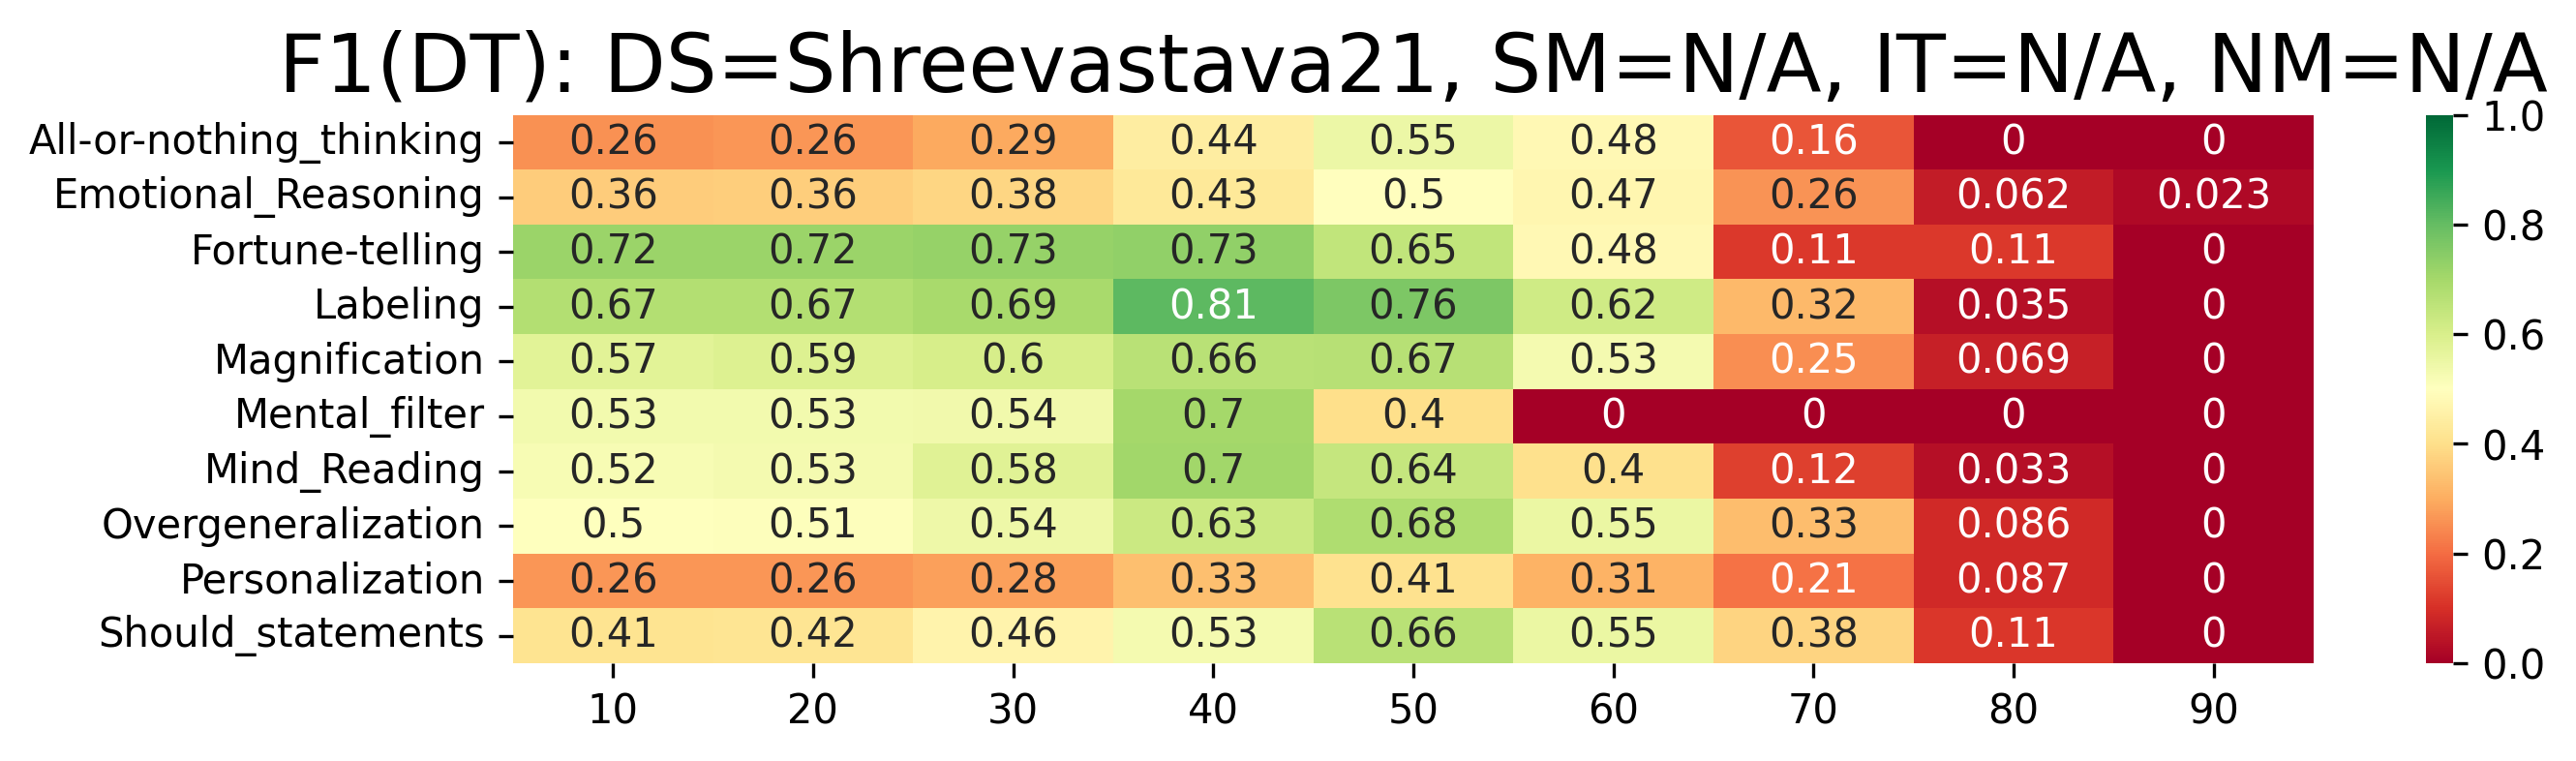

('N/A', 'N/A', 'N/A', 40, 0.596900997438391, {'All-or-nothing_thinking': 0.44318181818181823, 'Emotional_Reasoning': 0.4263959390862945, 'Fortune-telling': 0.7317073170731708, 'Labeling': 0.8095238095238095, 'Magnification': 0.662251655629139, 'Mental_filter': 0.7000000000000001, 'Mind_Reading': 0.7044025157232704, 'Overgeneralization': 0.6265664160401003, 'Personalization': 0.3339070567986231, 'Should_statements': 0.5310734463276836})
['All-or-nothing_thinking', 'Emotional_Reasoning', 'Fortune-telling', 'Labeling', 'Magnification', 'Mental_filter', 'Mind_Reading', 'Overgeneralization', 'Personalization', 'Should_statements']
[0.44, 0.43, 0.73, 0.81, 0.66, 0.7, 0.7, 0.63, 0.33, 0.53]
0.5960000000000001


In [44]:
# Evaluate joint model (ours 2026) without splits

all_metricsmap = {'All-or-nothing_thinking':'dichotomous-reasoning',
              'Fortune-telling':'fortune-telling',
              'Mental_filter':'mental-filtering',
              'Overgeneralization':'overgeneralizing',
              'Labeling':'labeling',
              'Mind_Reading':'mindreading',
              'Personalization':'personalizing',
              'Emotional_Reasoning':'emotional-reasoning',
              'Magnification':'magnification',
              'Should_statements':'should-statement'}

def language_metrics(lang,metrics_filenames,path):
    metrics = {}
    for m in metrics_filenames:
        filename = metrics_filenames[m] if type(metrics_filenames) == dict else m
        metrics[m] = path + lang + '/' + filename + '.txt'
    return metrics

tm_base = TextMetrics(language_metrics('',all_metricsmap,path='../../data/models/distortions/ours26')
                  ,encoding="utf-8",metric_logarithmic=True,debug=False)

detection_thresholds = [10,20,30,40,50,60,70,80,90]

accumulator = []
evaluate_metrics(tm_base, df, 'N/A', detection_thresholds, DS, list(all_metricsmap), n_max='N/A', 
                selection_metric = 'N/A', f1_score=True, evaluator=our_evaluator_top1, accumulator=accumulator)

best = sorted(accumulator, key=lambda x: (-x[4]))[0]
print(best)
labels = sorted(list(best[5]))
print(labels)
numbers_arinicheva = [round(best[5][label],2) for label in labels]
print(numbers_arinicheva)
print(sum(numbers_arinicheva)/len(numbers_arinicheva))

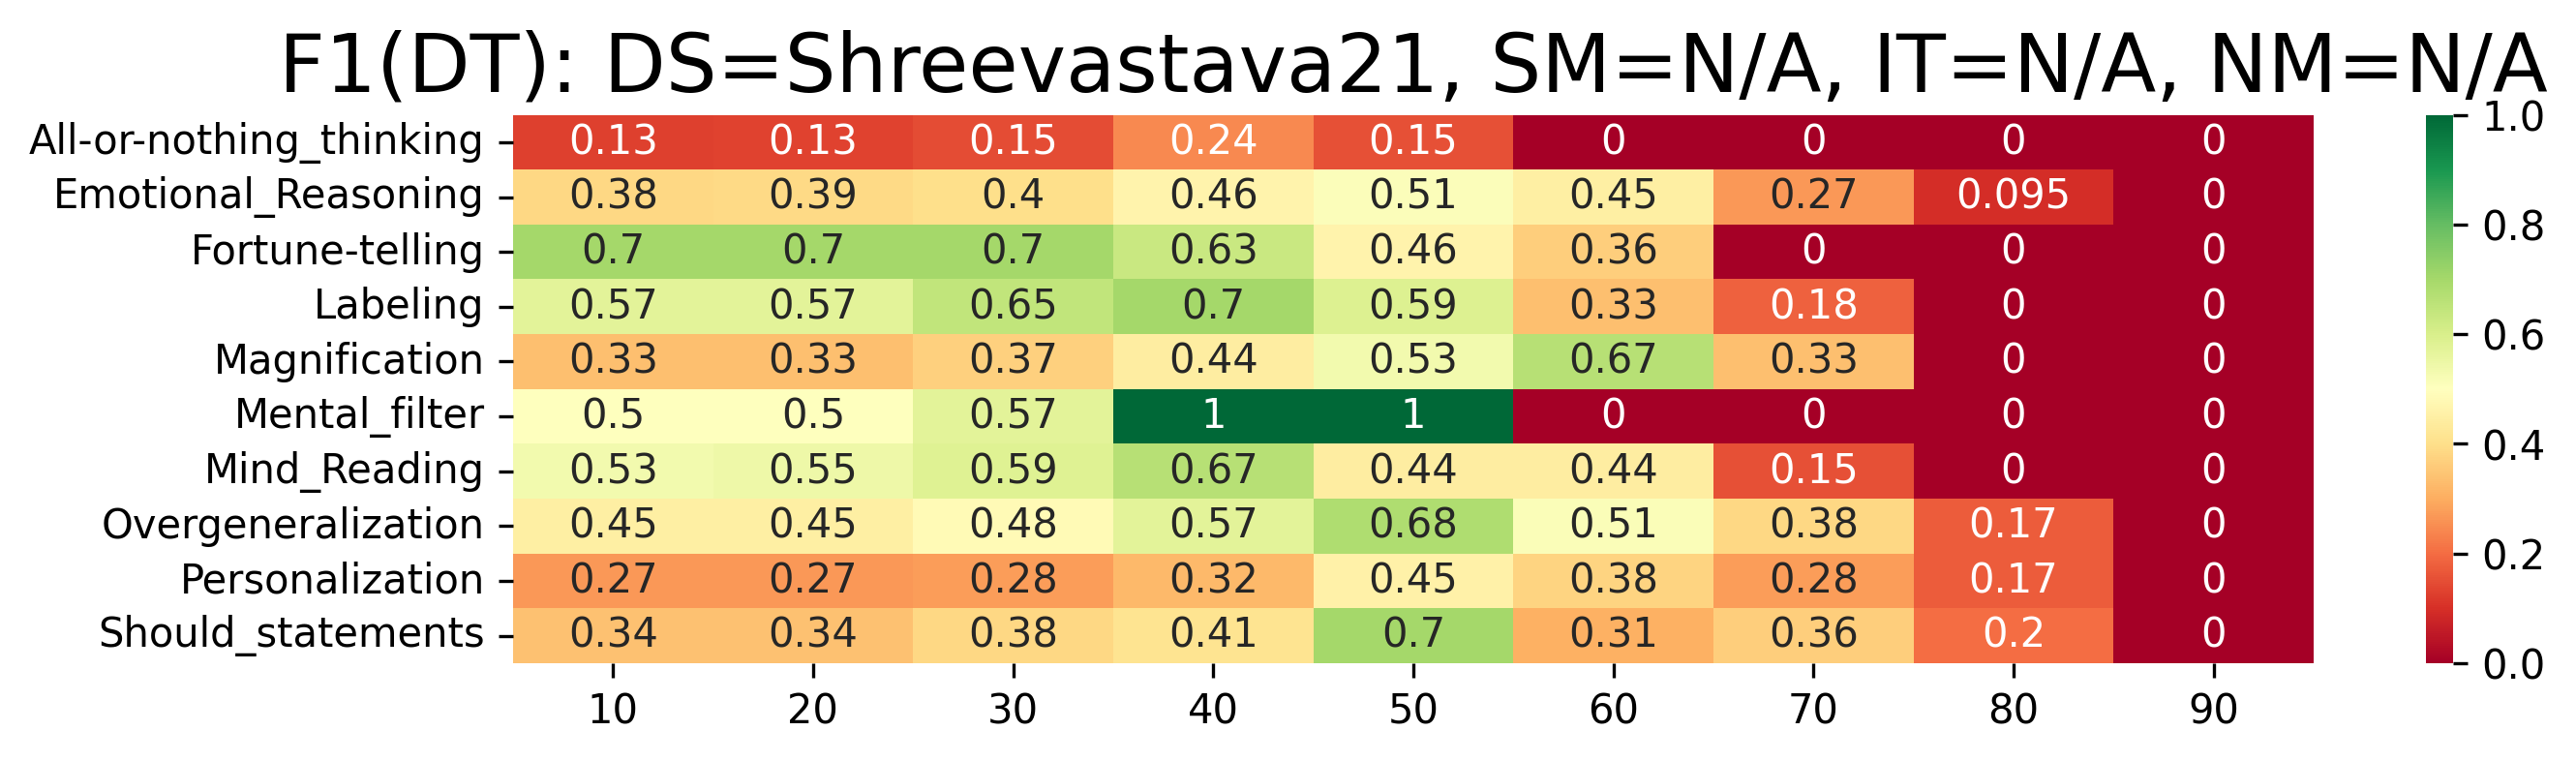

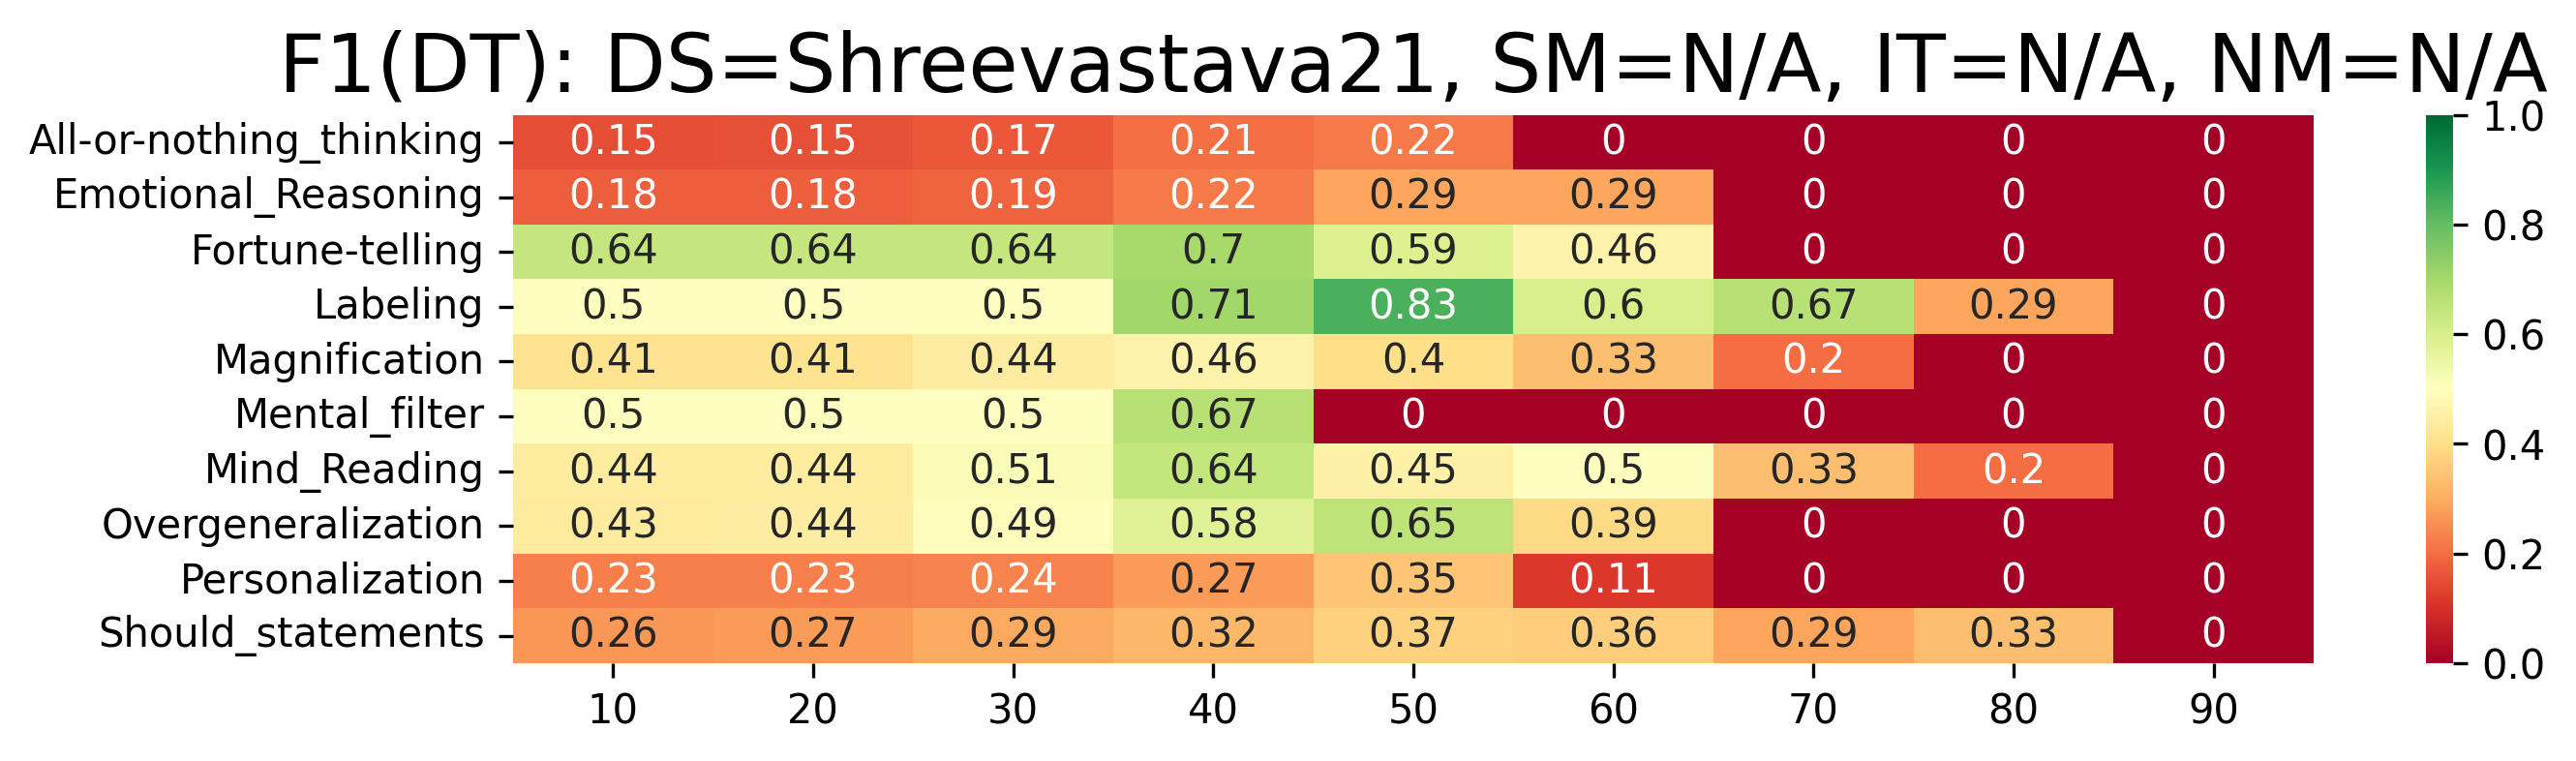

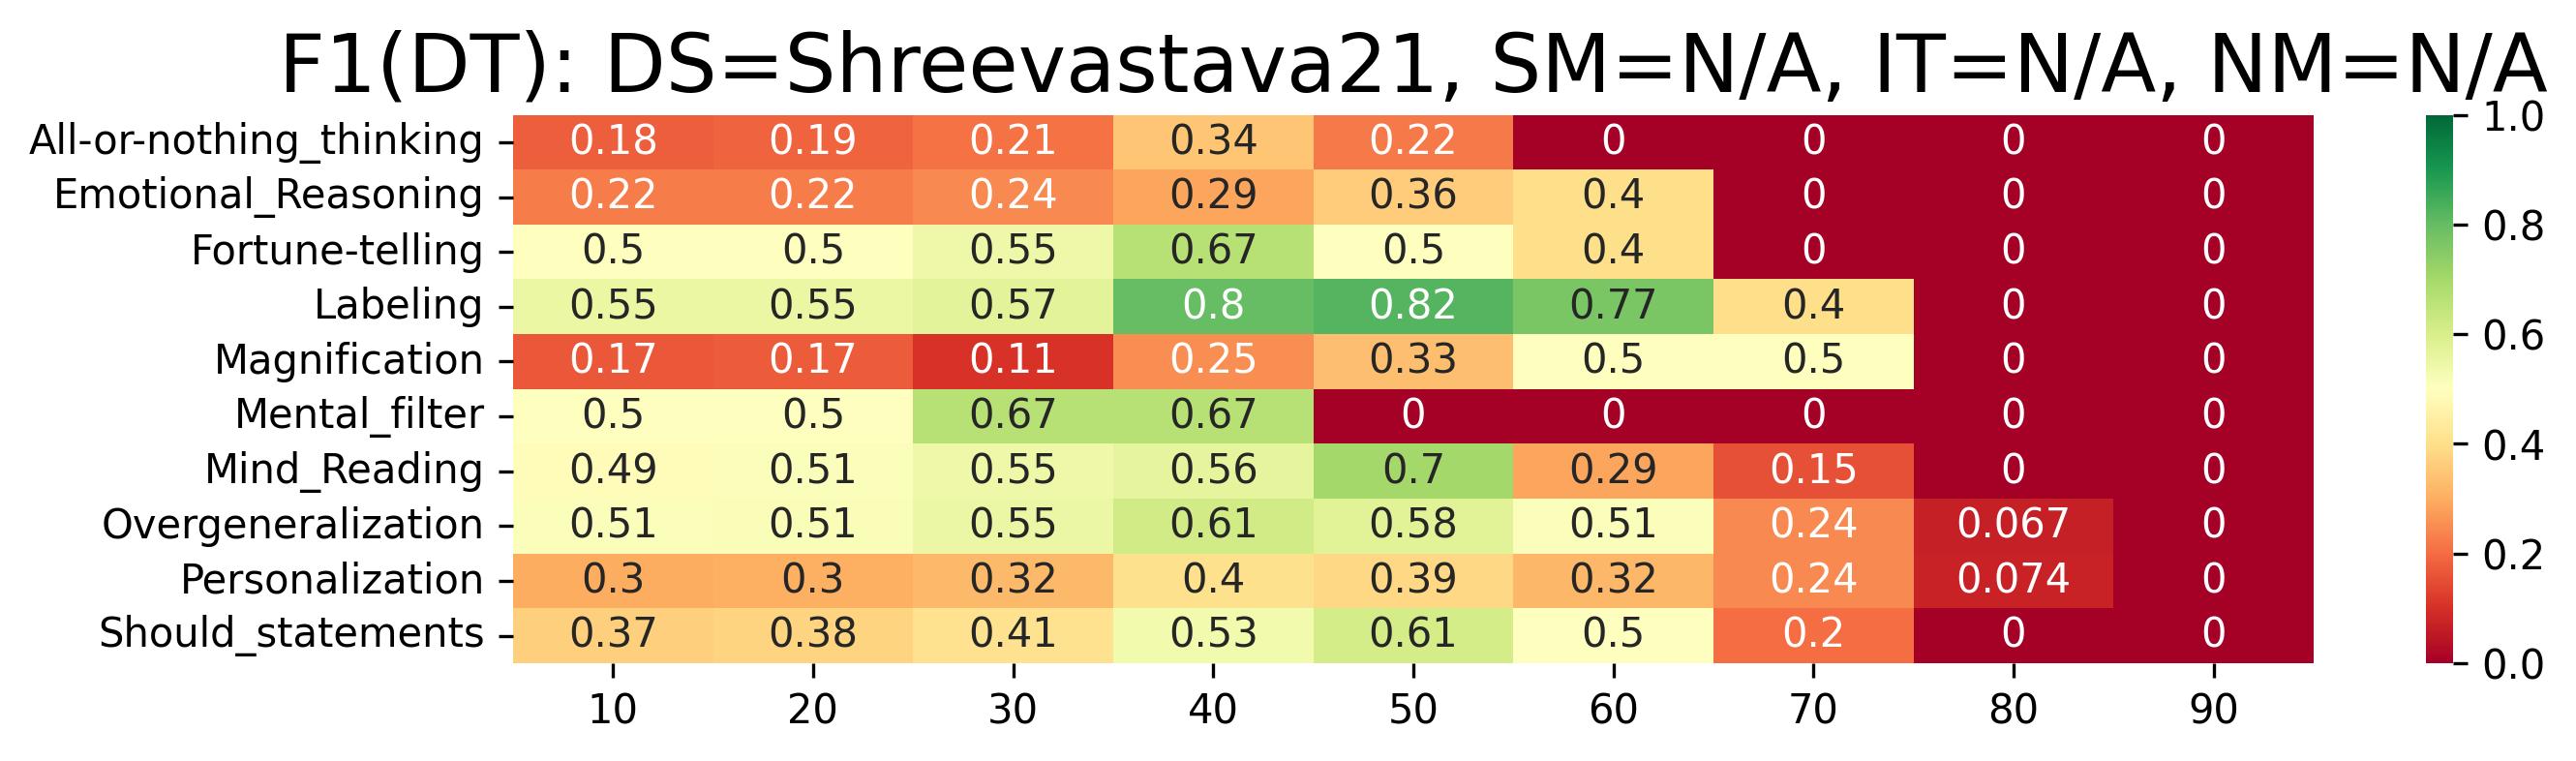

('N/A',
 'N/A',
 'N/A',
 40,
 0.47733902130111766,
 0.5452247815040183,
 0.5117402912242396,
 4.4816052872996)

In [45]:
# Evaluate joint model (ours 2026) within 3 splits
splits = [0,1,2]
validation_fraction = 5
results_base = []
for shift in splits:
    test_df  = df[(df.index + shift) % validation_fraction == 0]
    accumulator_base = []
    evaluate_metrics(tm_base, test_df, 'N/A', detection_thresholds, DS, list(all_metricsmap), n_max='N/A', 
                selection_metric = 'N/A', f1_score=True, evaluator=our_evaluator_top1, accumulator=accumulator_base)
    results_base.append(accumulator_base)

# Print F1 performance of baseline model (Arinicheva and Kolonin 2025) within 3 splits
summary_base = []
for l1,l2,l3 in zip(results_base[0],results_base[1],results_base[2]):
    summary_base.append( l1[0:4] + agg_min_max_avg_mpe((l1[4],l2[4],l3[4])))
summary_base = sorted(summary_base, key=lambda x: (-x[6],x[3])) # sort by -F1avg, DT
summary_base[0]

In [46]:
len(['catastrophizing', 'dichotoreasoning', 'disqualpositive',
       'emotionreasoning', 'fortunetelling', 'labeling', 'magnification',
       'mentalfiltering', 'mindreading', 'overgeneralizing', 'personalizing',
       'shouldment', 'exclusivereasoning', 'negativereasoning',
       'mentalfilteringplus'])

15

In [2]:
# Evaluate the computing time budget

grand_t1 = dt.datetime.now()
grand_delta = grand_t1 - grand_t0
str(grand_delta)

'0:00:00.005703'